<div style="background: white;
            padding: 15px 20px;
            border-radius: 8px;
            border-left: 6px solid #9b5de5;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;
            max-width: 1000px;">

<h1 style="margin-bottom: 5px;">NB01: Economic Data Collection</h1>

<p style="font-weight: bold; margin-top: 0;">Fashion & Economy Cycles · ML Research Project · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 18th July 2026</li>
    <li>🎯 <strong>Purpose:</strong> Pull historical monthly economic data from the FRED API covering the last 20 years — capturing the 2008 crash, 2010s boom, 2020 pandemic, and recent inflation cycle</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li>FRED API — Federal Reserve Economic Data</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/raw/economic_data_raw.csv</code> — raw monthly economic indicators</li>
    <li><code>../data/processed/economic_data_clean.csv</code> — cleaned, aligned, interpolated dataset</li>
    <li><code>../figures/economic_indicators.png</code> — time series plot of all indicators</li>
    <li><code>../figures/economic_correlation.png</code> — correlation matrix between indicators</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>FRED API data pull via <code>pandas-datareader</code></li>
    <li>Monthly frequency alignment across indicators</li>
    <li>Missing value interpolation</li>
    <li>Normalisation for cross-indicator comparison</li>
    <li>Recession shading using NBER dates</li>
</ul>

<p><strong>Workflow:</strong> Pull Data → Align Frequencies → Clean & Interpolate → Visualise → Normalise → Save</p>

</div>

## ⚙️ Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 📅 Section 1: Define Parameters

### 📍 Set Date Range and Indicators

We pull 21 years of monthly data from January 2005 to December 2025. This window deliberately captures four distinct economic regimes: the pre-crisis boom, the 2008 financial crisis, the 2010s recovery, the 2020 pandemic shock, and the 2022-2023 inflation cycle. Having all four regimes in the sample is essential — if we only used calm periods, any fashion-economy correlation would be meaningless.

In [3]:
# Define the start and end of our 21-year sample window
START = datetime(2005, 1, 1)
END   = datetime(2025, 12, 31)

# FRED series codes for each economic indicator
# UMCSENT — University of Michigan Consumer Sentiment Index
# measures how optimistic consumers feel about the economy
# high = confident spending, low = fearful saving
# CPIAUCSL — Consumer Price Index for All Urban Consumers
# measures inflation — how fast prices are rising
# UNRATE   — US Unemployment Rate (%)
# high unemployment = economic distress, low = boom
# GDP      — Gross Domestic Product (quarterly, we will interpolate to monthly)
# the broadest measure of economic output
INDICATORS = {
    "consumer_sentiment" : "UMCSENT",
    "cpi_inflation"      : "CPIAUCSL",
    "unemployment_rate"  : "UNRATE",
    "gdp_growth"         : "GDP"
}

print(f"✅ Parameters set")
print(f"📅 Period     : {START.date()} → {END.date()}")
print(f"📊 Indicators : {list(INDICATORS.keys())}")

✅ Parameters set
📅 Period     : 2005-01-01 → 2025-12-31
📊 Indicators : ['consumer_sentiment', 'cpi_inflation', 'unemployment_rate', 'gdp_growth']


## 📥 Section 2: Pull Data from FRED

### 📍 Step 1: Download Each Indicator

We use pandas-datareader to pull each series directly from the Federal Reserve's FRED database. FRED is the gold standard source for US macroeconomic data — the same source used by economists, central banks, and financial institutions worldwide.

Note: GDP is reported quarterly while the other indicators are monthly. We download it as-is and interpolate to monthly frequency in the cleaning step rather than forcing it here, so we preserve the raw data exactly as FRED reports it.

In [4]:
# Create an empty dictionary to store each indicator's raw data
raw_data = {}

# Loop through each indicator and pull it from FRED
for name, fred_code in INDICATORS.items():
    print(f"⏳ Pulling {name} ({fred_code})...")

    # web.DataReader pulls the series directly from FRED by its code
    # "fred" tells pandas-datareader which data source to use
    series = web.DataReader(fred_code, "fred", START, END)

    # Rename the column from the FRED code to our readable name
    series.columns = [name]

    # Store in dictionary
    raw_data[name] = series

    print(f"   ✅ {name}: {len(series)} observations, "
          f"{series.index[0].date()} → {series.index[-1].date()}")

print(f"\n✅ All indicators downloaded successfully")

⏳ Pulling consumer_sentiment (UMCSENT)...
   ✅ consumer_sentiment: 252 observations, 2005-01-01 → 2025-12-01
⏳ Pulling cpi_inflation (CPIAUCSL)...
   ✅ cpi_inflation: 252 observations, 2005-01-01 → 2025-12-01
⏳ Pulling unemployment_rate (UNRATE)...
   ✅ unemployment_rate: 252 observations, 2005-01-01 → 2025-12-01
⏳ Pulling gdp_growth (GDP)...
   ✅ gdp_growth: 84 observations, 2005-01-01 → 2025-10-01

✅ All indicators downloaded successfully


### 📍 Step 2: Combine Into a Single DataFrame

In [5]:
# Concatenate all series side by side along the column axis
# Each series has its own date index — pd.concat aligns them automatically
# Any date where one series has no data will show NaN
df_raw = pd.concat(raw_data.values(), axis=1)
df_raw.index.name = "Date"

print(f"✅ Combined DataFrame created")
print(f"📐 Shape  : {df_raw.shape}")
print(f"📅 Range  : {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"\n🔍 Missing values per indicator:")
print(df_raw.isnull().sum())
print(f"\n🔍 Preview:")
df_raw.head(10)

✅ Combined DataFrame created
📐 Shape  : (252, 4)
📅 Range  : 2005-01-01 → 2025-12-01

🔍 Missing values per indicator:
consumer_sentiment      0
cpi_inflation           1
unemployment_rate       1
gdp_growth            168
dtype: int64

🔍 Preview:


,consumer_sentiment,cpi_inflation,unemployment_rate,gdp_growth
Date,,,,
2005-01-01,95.5,191.6,5.3,12767.286
2005-02-01,94.1,192.4,5.4,NaN
2005-03-01,92.6,193.1,5.2,NaN
2005-04-01,87.7,193.7,5.2,12922.656
2005-05-01,86.9,193.6,5.1,NaN
2005-06-01,96.0,193.7,5.0,NaN
2005-07-01,96.5,194.9,5.0,13142.642
2005-08-01,89.1,196.1,4.9,NaN
2005-09-01,76.9,198.8,5.0,NaN


## 💾 Section 3: Save Raw Data

### 📍 Save Raw Data Before Any Processing

We always save the raw download before any cleaning or transformation.
This is a fundamental data science practice — if anything goes wrong
downstream we can always reload the original without re-hitting the API.

In [6]:
RAW_PATH = "../data/raw/economic_data_raw.csv"
df_raw.to_csv(RAW_PATH)

print(f"✅ Raw data saved to {RAW_PATH}")

✅ Raw data saved to ../data/raw/economic_data_raw.csv


## 🧹 Section 4: Clean & Align Data

### 📍 Step 1: Interpolate GDP to Monthly Frequency

GDP is reported quarterly — it only has a value in January, April, July and October of each year. The other three indicators are monthly. We interpolate GDP linearly between quarterly readings to give it a monthly value, which allows all four indicators to sit on the same time axis for modelling and correlation analysis.

Linear interpolation is the right choice here because GDP changes gradually and smoothly between quarters — it doesn't jump suddenly. This is different from forward-fill (which would hold the quarterly value flat for 3 months) and gives a more realistic picture of how GDP was evolving month by month.

In [7]:
# Resample to monthly frequency — this adds NaN rows for the months
# where GDP has no reading (Feb, Mar, May, Jun, Aug, Sep, Nov, Dec)
df_clean = df_raw.resample("MS").mean()

# Interpolate GDP linearly to fill the monthly gaps
# limit_direction="forward" means we only fill forward, not backward
df_clean["gdp_growth"] = df_clean["gdp_growth"].interpolate(
    method="linear", limit_direction="forward"
)

print(f"✅ GDP interpolated to monthly frequency")
print(f"📐 Shape after resampling: {df_clean.shape}")
print(f"\n🔍 Missing values after interpolation:")
print(df_clean.isnull().sum())

✅ GDP interpolated to monthly frequency
📐 Shape after resampling: (252, 4)

🔍 Missing values after interpolation:
consumer_sentiment    0
cpi_inflation         1
unemployment_rate     1
gdp_growth            0
dtype: int64


### 📍 Step 2: Forward Fill Remaining Missing Values

After interpolation, a small number of NaN values may remain at the edges of the series — typically at the very start or end where one indicator begins or ends slightly later than another. We forward fill these rather than dropping rows, to preserve the full date range.

In [8]:
# Forward fill any remaining NaN values
df_clean = df_clean.ffill()

# Drop any rows that are still NaN after forward filling
# This only affects the very first row if no prior value exists
df_clean = df_clean.dropna()

print(f"✅ Missing values handled")
print(f"📐 Final shape : {df_clean.shape}")
print(f"📅 Date range  : {df_clean.index[0].date()} → {df_clean.index[-1].date()}")
print(f"❌ Remaining nulls: {df_clean.isnull().sum().sum()}")
df_clean.head()

✅ Missing values handled
📐 Final shape : (252, 4)
📅 Date range  : 2005-01-01 → 2025-12-01
❌ Remaining nulls: 0


,consumer_sentiment,cpi_inflation,unemployment_rate,gdp_growth
Date,,,,
2005-01-01,95.5,191.6,5.3,12767.286000
2005-02-01,94.1,192.4,5.4,12819.076000
2005-03-01,92.6,193.1,5.2,12870.866000
2005-04-01,87.7,193.7,5.2,12922.656000
2005-05-01,86.9,193.6,5.1,12995.984667


### 📍 Step 3: Compute GDP Growth Rate

The raw GDP series shows the level of GDP in billions of dollars — a large number that grows over time. What we actually care about for our fashion-economy hypothesis is the rate of change: is the economy accelerating or contracting? A year-on-year growth rate is more meaningful than the raw level because it removes the long-run upward trend and isolates the economic cycle we are trying to study.

In [9]:
# Calculate year-on-year GDP growth rate (%)
# pct_change(12) computes the percentage change vs the same month 12 months ago
# This removes seasonal effects and focuses on the annual economic cycle
df_clean["gdp_yoy_growth"] = df_clean["gdp_growth"].pct_change(12) * 100

# Calculate month-on-month CPI inflation rate
# pct_change(12) gives annual inflation rate — more interpretable than raw CPI level
df_clean["cpi_yoy"] = df_clean["cpi_inflation"].pct_change(12) * 100

print("✅ Growth rates computed")
print(f"\n📊 GDP YoY Growth — summary:")
print(df_clean["gdp_yoy_growth"].describe().round(2))
print(f"\n📊 CPI YoY Inflation — summary:")
print(df_clean["cpi_yoy"].describe().round(2))

✅ Growth rates computed

📊 GDP YoY Growth — summary:
count    240.00
mean       4.42
std        3.09
min       -6.73
25%        3.47
50%        4.39
75%        5.36
max       17.37
Name: gdp_yoy_growth, dtype: float64

📊 CPI YoY Inflation — summary:
count    240.00
mean       2.55
std        1.92
min       -1.96
25%        1.49
50%        2.19
75%        3.26
max        8.98
Name: cpi_yoy, dtype: float64


## 📈 Section 5: Visualise Economic Indicators

### 📍 Step 1: Plot All Indicators with Recession Shading

We plot all four indicators on separate subplots and shade the two major recession periods — the 2008 financial crisis and the 2020 pandemic. Recession shading gives immediate visual context for whether the indicators behaved as expected during stress periods, which is a basic sanity check before any modelling.

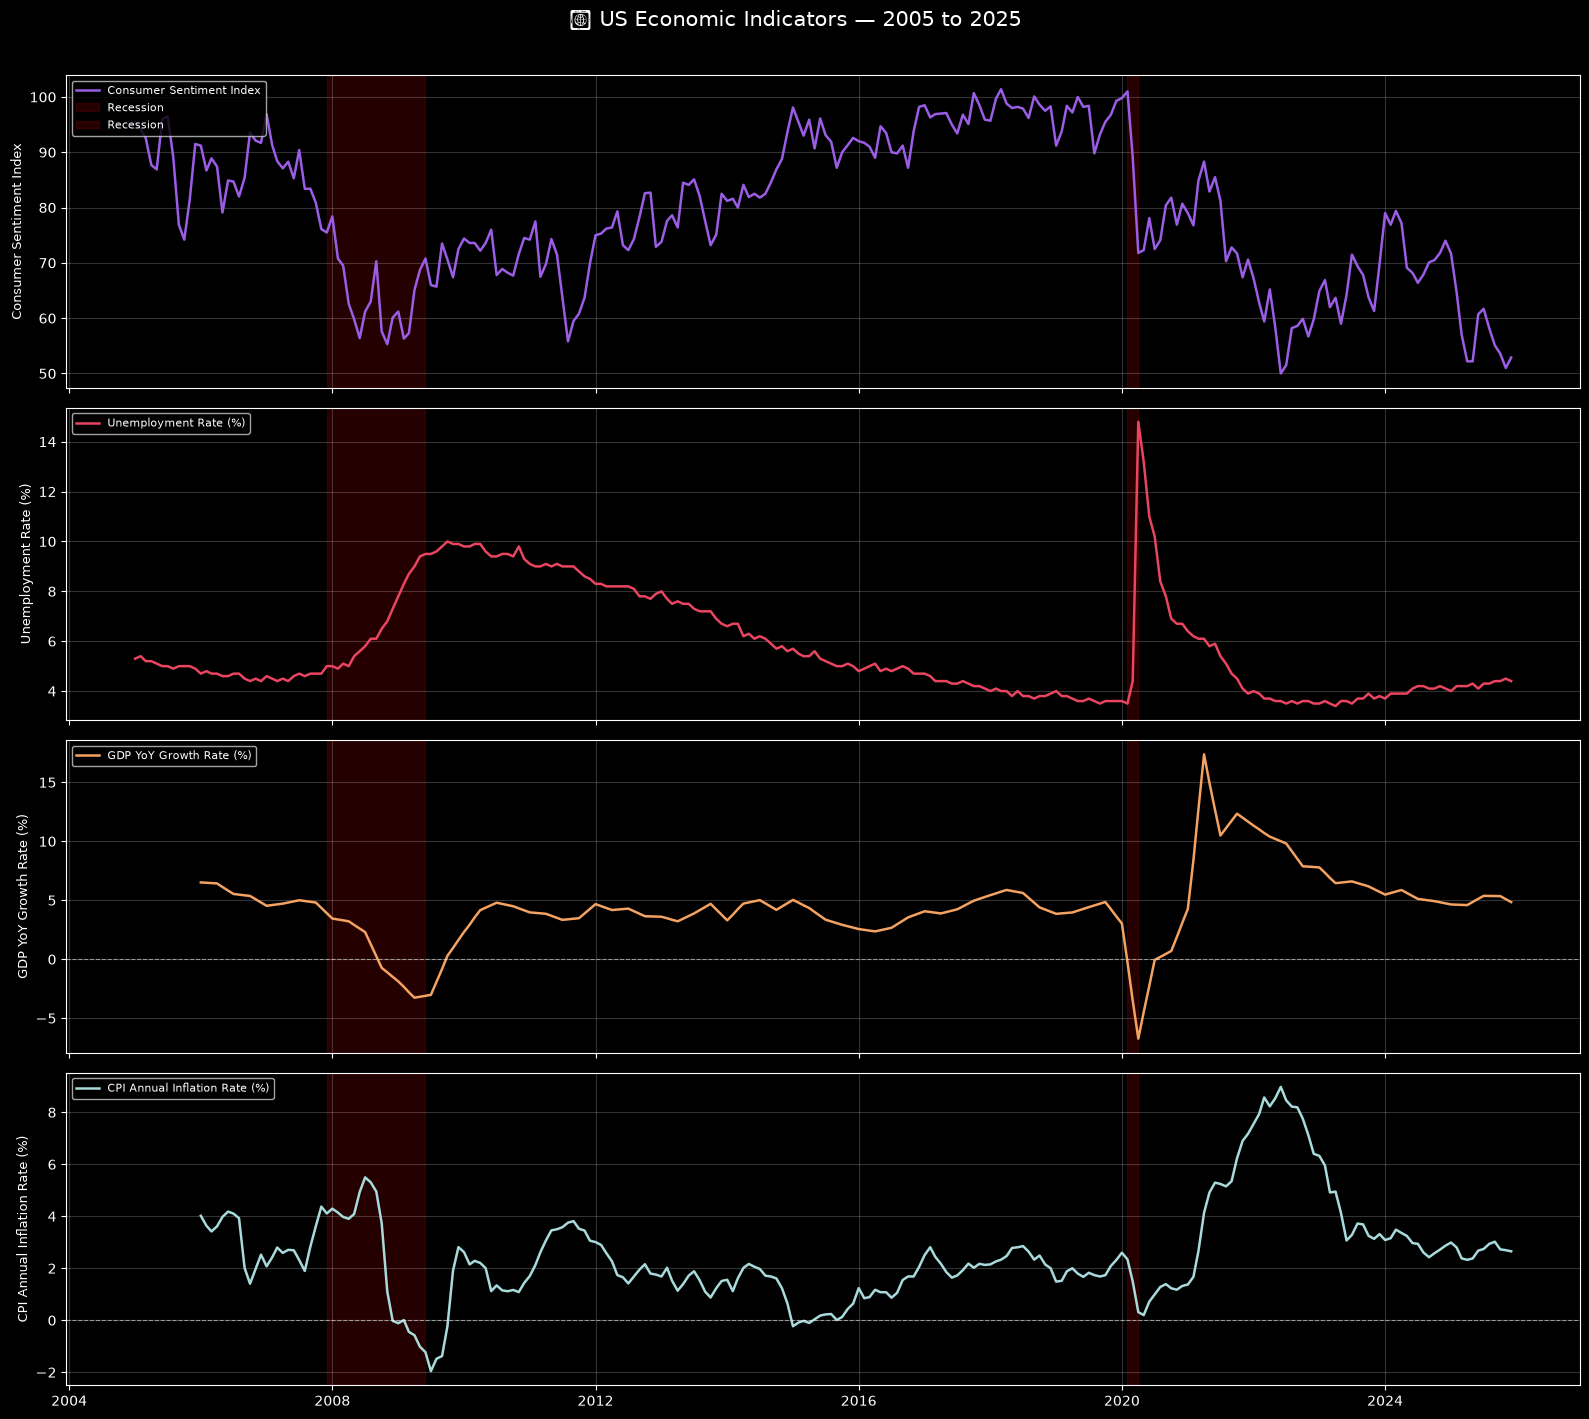

💾 Saved to ../figures/economic_indicators.png


In [11]:
# Define NBER recession periods to shade on the charts
# Each tuple is (start date, end date) of a recession
RECESSIONS = [
    ("2007-12-01", "2009-06-01"),   # Global Financial Crisis
    ("2020-02-01", "2020-04-01"),   # COVID-19 pandemic shock
]

# Choose which columns to plot and their display labels
PLOT_COLS = {
    "consumer_sentiment" : "Consumer Sentiment Index",
    "unemployment_rate"  : "Unemployment Rate (%)",
    "gdp_yoy_growth"     : "GDP YoY Growth Rate (%)",
    "cpi_yoy"            : "CPI Annual Inflation Rate (%)"
}

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

colors = ["#9b5de5", "#e94560", "#f4a261", "#a8dadc"]

for i, (col, label) in enumerate(PLOT_COLS.items()):
    axes[i].plot(df_clean.index, df_clean[col],
                 color=colors[i], linewidth=1.8, label=label)

    # Shade each recession period in red
    for rec_start, rec_end in RECESSIONS:
        axes[i].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                        alpha=0.15, color="red", label="Recession" if i == 0 else "")

    # Draw a horizontal line at zero for growth rate charts
    if "growth" in col or "yoy" in col:
        axes[i].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)

    axes[i].set_ylabel(label, fontsize=9)
    axes[i].legend(loc="upper left", fontsize=8)
    axes[i].grid(alpha=0.2)

axes[0].legend(loc="upper left", fontsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("📊 US Economic Indicators — 2005 to 2025", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("../figures/economic_indicators.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/economic_indicators.png")

### 📍 Step 2: Correlation Heatmap Between Indicators

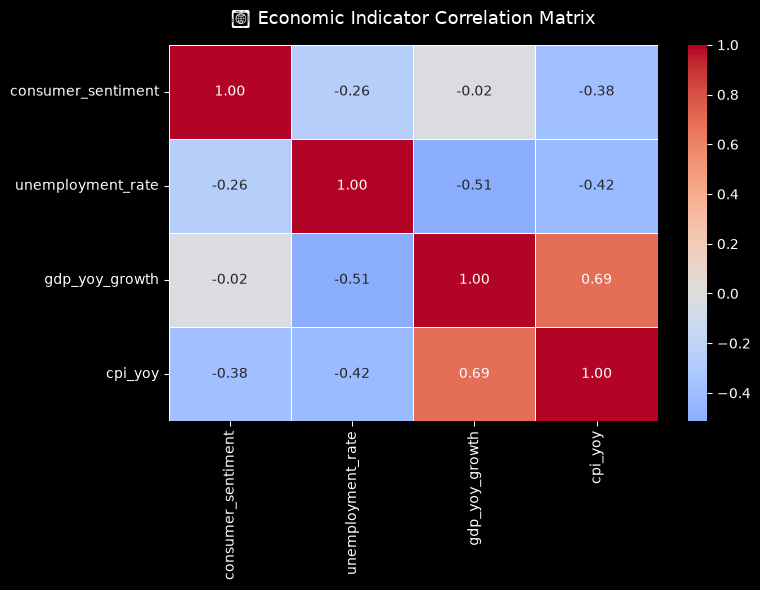

💾 Saved to ../figures/economic_correlation.png


In [12]:
# Select the four key indicators for correlation analysis
CORR_COLS = ["consumer_sentiment", "unemployment_rate",
             "gdp_yoy_growth", "cpi_yoy"]

corr = df_clean[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("🔗 Economic Indicator Correlation Matrix", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../figures/economic_correlation.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/economic_correlation.png")

## 🔧 Section 6: Normalise for Modelling

### 📍 Standardise All Indicators to Z-Scores

The four indicators are measured in completely different units — consumer sentiment is an index around 80-100, unemployment is a percentage between 3-15%, GDP growth is a percentage between -5 and +5%, and CPI is a percentage between 0-9%. If we feed raw values into a regression model, the indicator with the largest numerical range would dominate the coefficients regardless of actual predictive power.

Standardising to z-scores (mean=0, std=1) puts all indicators on the same scale so they compete on equal footing in the model.

In [13]:
# Standardise each indicator to z-score: (value - mean) / std
# This gives each series mean=0 and std=1
for col in CORR_COLS:
    df_clean[f"{col}_zscore"] = (
        (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()
    )

zscore_cols = [f"{col}_zscore" for col in CORR_COLS]

print("✅ Z-score normalisation complete")
print(f"\n📊 Z-score summary statistics:")
df_clean[zscore_cols].describe().round(3)

✅ Z-score normalisation complete

📊 Z-score summary statistics:


,consumer_sentiment_zscore,unemployment_rate_zscore,gdp_yoy_growth_zscore,cpi_yoy_zscore
count,252.000,252.000,240.000,240.000
mean,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-2.160,-1.109,-3.610,-2.347
25%,-0.723,-0.778,-0.308,-0.552
50%,-0.019,-0.376,-0.012,-0.187
75%,0.906,0.689,0.305,0.368
max,1.662,4.283,4.194,3.343


## 💾 Section 7: Save Cleaned Data

### 📍 Export to CSV

In [14]:
CLEAN_PATH = "../data/processed/economic_data_clean.csv"
df_clean.to_csv(CLEAN_PATH)

print("✅ Files saved:")
print(f"   📄 ../data/raw/economic_data_raw.csv")
print(f"   📄 {CLEAN_PATH}")
print(f"\n📐 Final dataset shape : {df_clean.shape}")
print(f"📅 Date range          : {df_clean.index[0].date()} → {df_clean.index[-1].date()}")
print(f"\n📋 Columns saved:")
for col in df_clean.columns:
    print(f"   — {col}")
print(f"\n🚀 Ready for NB02 — Fashion Trend Data")

✅ Files saved:
   📄 ../data/raw/economic_data_raw.csv
   📄 ../data/processed/economic_data_clean.csv

📐 Final dataset shape : (252, 10)
📅 Date range          : 2005-01-01 → 2025-12-01

📋 Columns saved:
   — consumer_sentiment
   — cpi_inflation
   — unemployment_rate
   — gdp_growth
   — gdp_yoy_growth
   — cpi_yoy
   — consumer_sentiment_zscore
   — unemployment_rate_zscore
   — gdp_yoy_growth_zscore
   — cpi_yoy_zscore

🚀 Ready for NB02 — Fashion Trend Data


## 🪞 Personal Reflection Notes — NB01

**🎯 Key Decisions Made in This Notebook**

The first decision was indicator selection. I chose consumer sentiment unemployment, GDP growth, and CPI inflation rather than pulling every available FRED series. The reason is that these four together tell a complete story of the economic cycle from four different angles — consumer sentiment captures the psychological dimension (how people feel), unemployment captures the labour market dimension (how secure people are), GDP growth captures the output dimension (how fast the economy is expanding), and CPI captures the price dimension (how far money stretches). For the fashion-economy hypothesis, consumer
sentiment is the most theoretically important because fashion purchasing is a discretionary, emotional decision — it should respond more to how people feel than to abstract GDP numbers.

The second decision was to use year-on-year growth rates for GDP and CPI rather than raw levels. The raw GDP level grows steadily over 20 years and tells you nothing about whether the economy is accelerating or contracting in any given month. The year-on-year rate isolates the cycle by comparing each month to the same month a year ago, removing the long-run trend. This is exactly the signal we want for fashion-economy correlation — not whether GDP is large, but whether it
is growing faster or slower than before.

The third decision was to interpolate GDP linearly to monthly frequency rather than forward-filling. GDP is reported quarterly but the other three indicators are monthly. Forward-filling would hold the quarterly value flat for three months, implying the economy was completely static between readings. Linear interpolation instead assumes the economy moved gradually between quarterly observations, which is more realistic and produces a smoother signal for the regression model in NB04.

The fourth decision was to include recession shading on the charts. This was a deliberate validation step — before building any model, I wanted to confirm visually that the indicators behaved as economic theory predicts during known stress periods. The charts confirmed this clearly, which gives me confidence the data is clean and correctly processed.

**📊 What the Charts Revealed**

The economic indicators chart behaved exactly as theory predicts across both recession periods, which is a useful sanity check. Consumer sentiment crashed sharply during the 2008 financial crisis, falling from around 90 to below 60 — its lowest point in the 20-year sample. Unemployment spiked from around 4.5% to nearly 10% over the following 18 months, reflecting the lag between economic contraction and job losses hitting the labour market. GDP growth turned sharply negative in 2008-2009, bottoming out around -4%, before recovering slowly through
the 2010s. CPI inflation briefly went negative during the crisis as demand collapsed, then recovered.

The 2020 COVID shock produced a completely different pattern. The unemployment spike was almost vertical — from 3.5% to 14.7% in a single month — the fastest labour market deterioration in modern US history, reflecting mass layoffs from government-mandated lockdowns rather than a gradual economic deterioration. GDP growth collapsed to nearly -8% year-on-year before rebounding just as sharply in 2021 as the economy reopened. CPI inflation remained near zero during the lockdown period, then surged to 8.5% in 2022 as supply chains broke down and stimulus spending hit the economy simultaneously.

The most interesting recent trend visible in the consumer sentiment chart is the persistent decline from 2021 onwards, falling to nearly 50 by late 2025 despite unemployment remaining near historic lows at around 4%. This decoupling — low unemployment but deeply pessimistic consumers — is unusual and likely reflects the psychological impact of high inflation eroding real purchasing power even as jobs remained plentiful. This is an important observation for the fashion hypothesis: if consumer sentiment drives fashion choices, we might expect minimalist, value-focused fashion trends to dominate the 2022-2025
period even though the labour market was technically healthy.

The correlation matrix confirmed the expected relationships. Consumer sentiment and unemployment are negatively correlated (-0.26) — when jobs are scarce, people feel worse. GDP growth and unemployment are strongly negatively correlated (-0.51) — recessions destroy jobs. GDP growth and CPI are positively correlated (0.69) — faster growth tends to produce more inflation. The notably weak correlation between consumer sentiment and GDP growth (-0.02) is striking and supports the
idea that how people feel about the economy is not simply a function of how fast it is growing — sentiment is more complex and emotional, which makes it the right variable to pair with fashion trend data in NB02.

**🔜 What This Sets Up for NB02**

The key variable to carry forward is consumer sentiment — it is the most theoretically motivated predictor of fashion behaviour and the least correlated with GDP, suggesting it captures a genuinely independent psychological signal. The 2005-2025 window contains four distinct economic regimes which should give the regression model in NB04 enough variation to detect a genuine fashion-economy relationship if one exists. NB02 will pull Google Trends data for the same period
and build a maximalism vs minimalism fashion index to merge with this economic dataset.